# Canada Health Indicators - Exploratory Data Analysis

Author: Angela Lekivetz

This notebook explores health indicator data from Statistics Canada (table 13-10-0096-01), 
covering 32 indicators across 10 provinces from 2015 to 2022. 

Four questions are explored:
1. Which indicators vary most across provinces?
2. How did COVID-19 impact health indicators between 2019 and 2020?
3. Are there significant differences in health outcomes between males and females?
4. Which provinces consistently perform best and worst across health indicators?

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

In [82]:
# Load bronze-layer dataset
df = pd.read_csv('bronze_health_indicators.csv', low_memory=False)

# Drop irrelevant columns and rename relevant columns
df = df.drop(columns=[
    'SYMBOL', 'TERMINATED', 'DGUID', 'STATUS', 'SCALAR_FACTOR', 
    'SCALAR_ID', 'VECTOR', 'COORDINATE', 'UOM_ID', 'DECIMALS'])
df = df.rename(columns={
    'REF_DATE': 'year',
    'GEO': 'province',
    'Age group': 'age_group',
    'Sex': 'sex',
    'Indicators': 'indicator',
    'Characteristics': 'characteristic',
    'UOM': 'unit_of_measure',
    'VALUE': 'value'
})

# Keep only percentage and number of persons for characteristics
df = df[df['characteristic'].isin(['Number of persons', 'Percent'])]

# Verify columns and shape
print(df.columns.tolist())
print(df.shape)

['year', 'province', 'age_group', 'sex', 'indicator', 'characteristic', 'unit_of_measure', 'value']
(83908, 8)


## 1. Indicator Variance Across Provinces

Which health indicators show the largest gaps between the best and the worst performing province? 

In [83]:
df1 = df[
    (df['characteristic'] == 'Percent') & 
    (df['sex'] == 'Both sexes') &
    (df['age_group'] == 'Total, 12 years and over') &
    (df['province'] != 'Canada (excluding territories)')
]

df1_grouped = df1.groupby('indicator')['value'].agg(['max', 'min'])
df1_grouped['range'] = df1_grouped['max'] - df1_grouped['min']
df1_grouped = df1_grouped.sort_values('range', ascending=False)
print(df1_grouped.head(10))

                                                     max   min  range
indicator                                                            
Exclusive breastfeeding, at least 6 months          54.2  15.4   38.8
Self-reported physical activity, average 60 min...  69.2  31.1   38.1
Influenza immunization in the past 12 months        56.5  20.5   36.0
Breast milk feeding initiation                      99.2  64.3   34.9
Fruit and vegetable consumption, 5 times or mor...  38.8  11.9   26.9
Perceived mental health, very good or excellent     75.3  49.4   25.9
Body mass index, self-reported, youth (12 to 17...  39.8  15.0   24.8
Body mass index, adjusted self-reported, adult ...  44.7  20.3   24.4
Sense of belonging to local community, somewhat...  80.5  57.9   22.6
Has a regular healthcare provider                   93.6  72.2   21.4


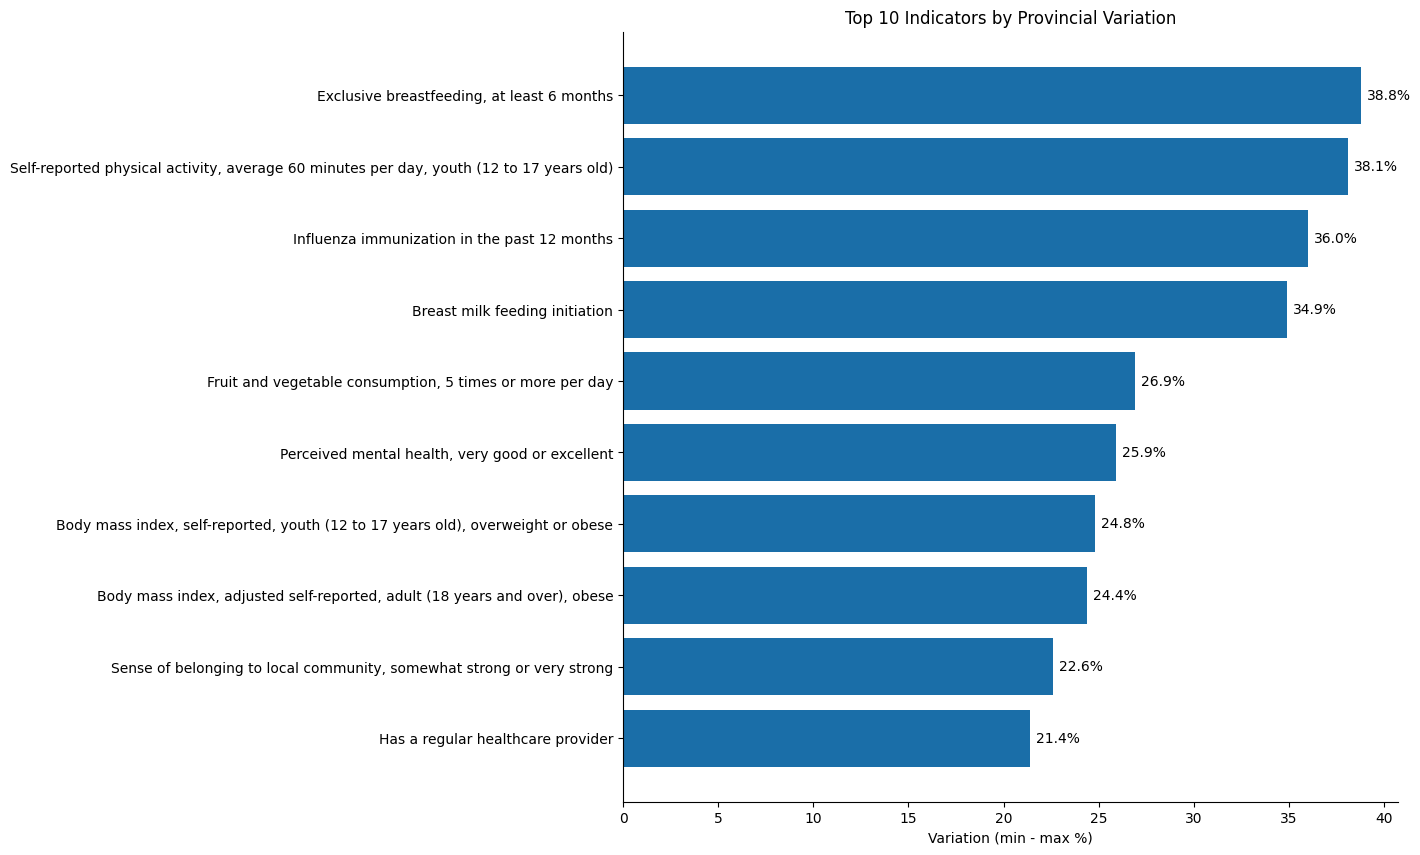

In [84]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(
    df1_grouped.head(10).index, 
    df1_grouped.head(10)['range'],
    color='#1A6EA8'
)

ax.invert_yaxis()
ax.set_xlabel('Variation (min - max %)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(df1_grouped.head(10)['range']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.title('Top 10 Indicators by Provincial Variation')

plt.savefig('images/eda_indicator_variance.png', dpi=150, bbox_inches='tight')
plt.show()


Exclusive breastfeeding and physical activity show the largest provincial 
variation at nearly 39 percentage points. Perceived mental health and healthcare provider 
access are the most policy-relevant indicators, with gaps of 26 and 21 percentage points 
respectively, suggesting significant regional inequality in health outcomes across Canada.

## 2. COVID Impact Analysis

How did health indicators change at the beginning of the pandemic? 


In [85]:
df2 = df1[
    (df1['year'] == 2019) | 
    (df1['year'] == 2020)
]

df2_grouped = df2.groupby(['indicator', 'year'])['value'].mean()
df2_pivot = df2_grouped.unstack('year')
df2_pivot['change'] = df2_pivot[2020] - df2_pivot[2019]
df2_pivot = df2_pivot.sort_values('change')
print(df2_pivot)

year                                                     2019       2020  \
indicator                                                                  
Self-reported physical activity, average 60 min...  58.033333  45.400000   
Breast milk feeding initiation                      94.850000  89.050000   
Body mass index, self-reported, youth (12 to 17...  28.790000  24.966667   
Self-reported physical activity, 150 minutes pe...  57.466667  53.870000   
Heavy drinking                                      19.940000  17.940000   
Current smoker, daily or occasional                 15.940000  13.980000   
Fruit and vegetable consumption, 5 times or mor...  24.475000  22.570000   
Arthritis (15 years and over)                       22.230000  21.120000   
Current smoker, daily                               11.020000   9.990000   
Perceived mental health, very good or excellent     65.230000  64.650000   
Perceived health, fair or poor                      12.340000  11.900000   
Cannabis use

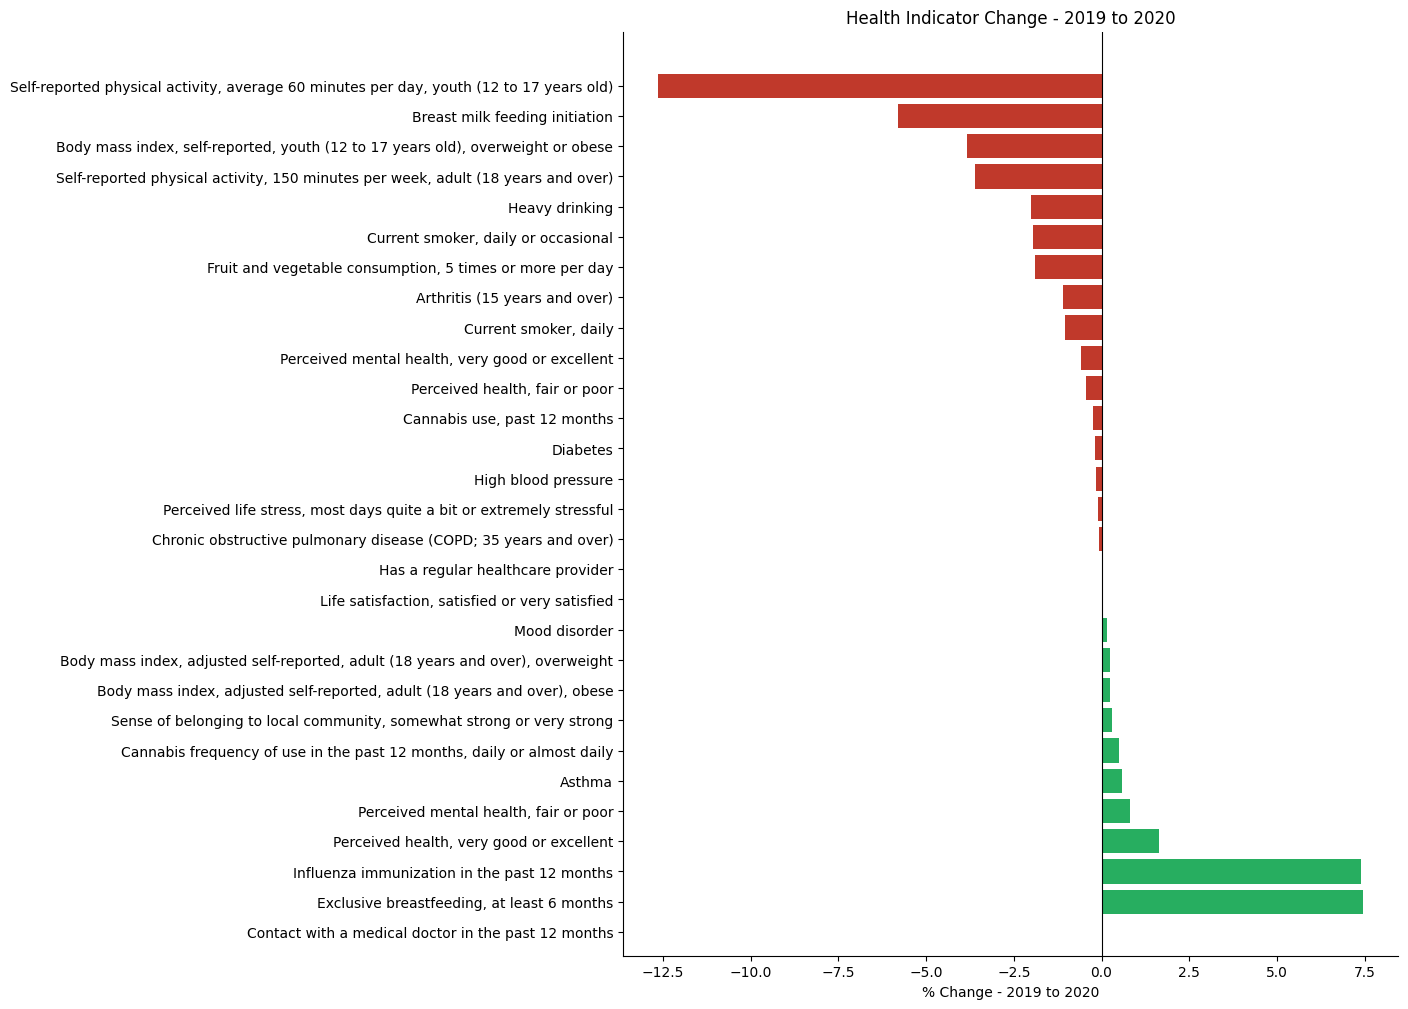

In [86]:
colors = ['#c0392b' if x < 0 else '#27ae60' for x in df2_pivot['change']]

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    df2_pivot.index, 
    df2_pivot['change'],
    color=colors
)

ax.invert_yaxis()
ax.set_xlabel('% Change - 2019 to 2020')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=0, color='black', linewidth=0.8)

plt.title('Health Indicator Change - 2019 to 2020')
plt.savefig('images/covid_impact.png', dpi=150, bbox_inches='tight')

plt.show()


We see from the chart that self reported physical activity of all ages decreased, which is expected as more people were staying home. Overweight and obese reportings in adults increased, however youth overweight/obese BMI reporting decreased. This could be due to self-reporting being less accurate during the pandemic, not necessarily to a real health improvement. 

Mental health reportings of 'good' and 'fair' decreased, whereas 'fair' mental health and 'excellent' overalln health both increased. We also saw a decrease in heavy drinking and current smokers. This indicates that people were trying to take care of themselves physically, but mentally were doing much worse. Sense of belonging to community increasing is interesting as people were isolating, possibly leading them to connect with others in new or different ways. 

Influenza vaccination went up as we would expect. Exclusive breastfeeding increased while initiation of breastfeeding decreased, indicating that less people were breastfeeding but those who did continued longer.

## 3. Gender Differences

Are there indicators where men and women diverge significantly?

In [87]:
df3 = df[
    (df['characteristic'] == 'Percent') & 
    (df['sex'] != 'Both sexes') &
    (df['age_group'] == 'Total, 12 years and over') &
    (df['province'] != 'Canada (excluding territories)')
]

df3_grouped = df3.groupby(['indicator', 'sex'])['value'].mean()
df3_pivot = df3_grouped.unstack('sex')
df3_pivot['diff'] = df3_pivot['Males'] - df3_pivot['Females']
df3_pivot = df3_pivot.sort_values('diff')
print(df3_pivot)

sex                                                   Females      Males  \
indicator                                                                  
Contact with a medical doctor in the past 12 mo...  81.040000  69.780000   
Fruit and vegetable consumption, 5 times or mor...  30.250000  19.366667   
Anxiety disorder                                    19.880000  11.190000   
Influenza immunization in the past 12 months        40.788571  33.734286   
Has a regular healthcare provider                   88.445000  81.437500   
Arthritis (15 years and over)                       24.665000  18.661250   
Mood disorder                                       12.555000   7.379747   
Perceived life stress, most days quite a bit or...  20.786250  17.771250   
Asthma                                               9.563333   7.001667   
Perceived mental health, fair or poor               10.410000   8.351899   
Sense of belonging to local community, somewhat...  71.991250  71.580000   
Perceived he

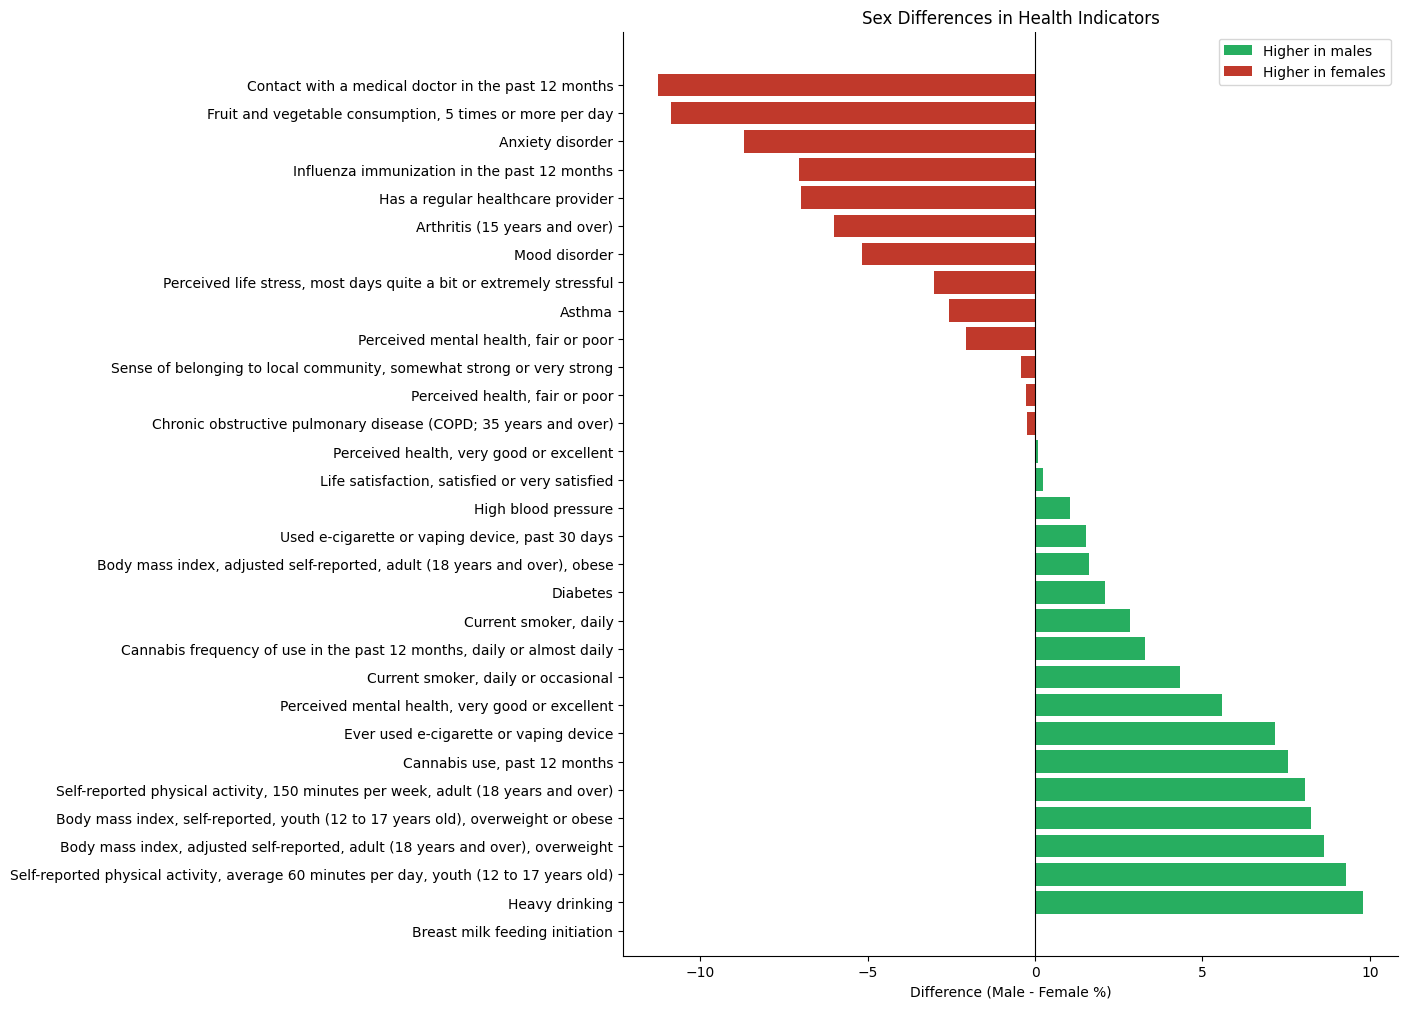

In [88]:
colors = ['#c0392b' if x < 0 else '#27ae60' for x in df3_pivot['diff']]

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    df3_pivot.index, 
    df3_pivot['diff'],
    color=colors
)

legend_elements = [
    Patch(facecolor='#27ae60', label='Higher in males'),
    Patch(facecolor='#c0392b', label='Higher in females')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.invert_yaxis()
ax.set_xlabel('Difference (Male - Female %)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=0, color='black', linewidth=0.8)

plt.title('Sex Differences in Health Indicators')
plt.savefig('images/gender_difference.png', dpi=150, bbox_inches='tight')

plt.show()


From the chart we see that women were more likely to see a doctor and get vaccinated, as well as eat healthy, indicating that on average women are more likely to take care of themselves physically. However, they also report higher levels of stress stress amd mood disorders like anxiety. This could be due to having more familial stress being caretakers.

Men were more likely to report smoking/vaping, using cannabis, and heavy drinking which had the highest difference in men vs women. Men are also likely to report higher bmi for all ages, but are also more likely to report higher excercise minutes for all ages. Men are also more likely to report 'very good' or 'excellent' mental health when compared to women. However, the gap between higher substance abuse and higher mental health ratings may suggest mental health underreporting. 

## 4. Provincial Rankings

Which provinces consistently rank highest and lowest across all health indicators? 

In [123]:
positive_indicators = [
    'Perceived health, very good or excellent',
    'Perceived mental health, very good or excellent',
    'Self-reported physical activity, 150 minutes per week, adult (18 years and over)',
    'Self-reported physical activity, average 60 minutes per day, youth (12 to 17 years old)',
    'Breast milk feeding initiation',
    'Exclusive breastfeeding, at least 6 months',
    'Fruit and vegetable consumption, 5 times or more per day',
    'Sense of belonging to local community, somewhat strong or very strong',
    'Life satisfaction, satisfied or very satisfied',
    'Has a regular healthcare provider',
    'Contact with a medical doctor in the past 12 months',
    'Influenza immunization in the past 12 months'
]

negative_indicators = [
    'Perceived health, fair or poor',
    'Perceived mental health, fair or poor',
    'Perceived life stress, most days quite a bit or extremely stressful',
    'Body mass index, adjusted self-reported, adult (18 years and over), overweight',
    'Body mass index, adjusted self-reported, adult (18 years and over), obese',
    'Body mass index, self-reported, youth (12 to 17 years old), overweight or obese',
    'Arthritis (15 years and over)',
    'Diabetes',
    'Asthma',
    'Chronic obstructive pulmonary disease (COPD; 35 years and over)',
    'High blood pressure',
    'Mood disorder',
    'Current smoker, daily or occasional',
    'Current smoker, daily',
    'Heavy drinking',
    'Cannabis use, past 12 months',
    'Cannabis frequency of use in the past 12 months, daily or almost daily',
    'Anxiety disorder',
    'Ever used e-cigarette or vaping device',
    'Used e-cigarette or vaping device, past 30 days'  
]

df_positive = df1[df1['indicator'].isin(positive_indicators)]
df_negative = df1[df1['indicator'].isin(negative_indicators)] 

df_positive_grouped = df_positive.groupby('province')['value'].mean().sort_values(ascending=False)
df_negative_grouped = df_negative.groupby('province')['value'].mean().sort_values(ascending=True)

print(df_positive_grouped)
print()
print(df_negative_grouped)

province
British Columbia             65.480488
Alberta                      63.853086
Ontario                      63.421795
Nova Scotia                  63.250633
Prince Edward Island         62.871795
Saskatchewan                 62.803704
Manitoba                     62.669231
Newfoundland and Labrador    61.942308
New Brunswick                61.941250
Quebec                       60.478205
Name: value, dtype: float64

province
British Columbia             15.247244
Quebec                       15.430709
Ontario                      16.112598
Alberta                      16.356693
Manitoba                     16.537008
Prince Edward Island         17.274603
Saskatchewan                 17.374803
New Brunswick                18.370079
Nova Scotia                  19.160630
Newfoundland and Labrador    19.525984
Name: value, dtype: float64


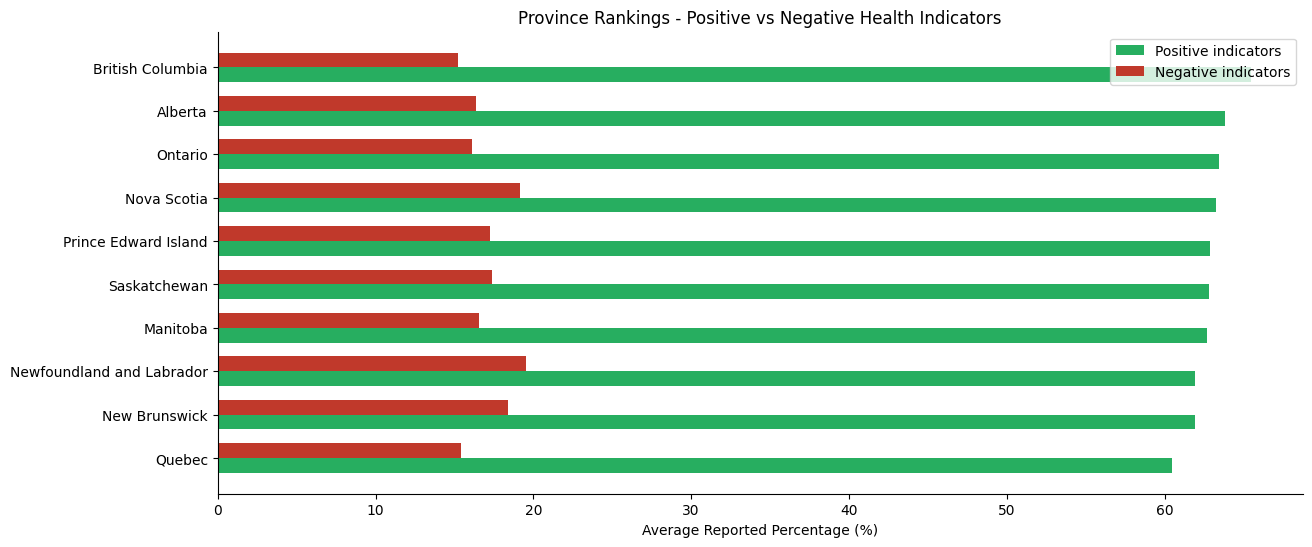

In [129]:
provinces = df_positive_grouped.index
df_negative_grouped = df_negative_grouped.reindex(df_positive_grouped.index)

y = np.arange(len(provinces))
height = 0.34

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(y + height/2, df_positive_grouped.values, height, label='Positive indicators', color='#27ae60')
ax.barh(y - height/2, df_negative_grouped.values, height, label='Negative indicators', color='#c0392b')

ax.invert_yaxis()
ax.set_yticks(y)
ax.set_yticklabels(provinces, ha='right')
ax.set_xlabel('Average Reported Percentage (%)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best')

plt.title('Province Rankings - Positive vs Negative Health Indicators')
plt.savefig('images/provincial_rankings.png', dpi=150, bbox_inches='tight')

plt.show()

From the chart, BC stands out as having the most reports of positive health indicators (65%) and the lowest reported negative indicators (15%), making it the strongest overall performer. Ontario follows a similar pattern, being among the highest reported positive health indicators and the lowest reported negative indicators.

Quebec residents have an interesting health profile, reporting the fewest positive health indicators (60%), while simultaneously having the second lowest reported negative indicators

New Brunswick and Newfoundland and Labrador are the worst performers, with residents ranking low for positive indicators (62% for both) and high for negative indicators (18% and 20%). 

In [134]:
print(df1['age_group'].unique())

<StringArray>
['Total, 12 years and over']
Length: 1, dtype: str
